### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Input data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 30       # number of modelling nodes

In [6]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [7]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
E = 207e9
G = 79.3e9

In [10]:
# integration parameters
tspan = (0., 2)

### Main functions:

In [11]:
Ar=np.pi*(d0/2)**2

In [12]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [13]:
def Ret_e_t(φ,θ,ψ):
    Cφ=np.array([[1,0,0],
                  [0,np.cos(φ),-np.sin(φ)],
                  [0,np.sin(φ),np.cos(φ)]])

    Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                  [0,1,0],
                  [-np.sin(θ),0,np.cos(θ)]])

    Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                  [np.sin(ψ),np.cos(ψ),0],
                  [0,0,1]])

    return Cθ @ Cφ @ Cψ

In [14]:
diag_J_t_rho = 1e2*np.array([1, 1, 2])  
J_t_rho = np.diag(diag_J_t_rho)

In [15]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [16]:
diag_CR = 1e11*np.array([1, 1, 1]) 
CR=np.diag(diag_CR)

In [17]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [18]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [19]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [20]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [21]:
def ωe(φ,θ,ψ): 
    return Πe(φ,θ,ψ)@theta(φ,θ,ψ)

In [22]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [23]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x1,y1,z1)-phi(x2,y2,z2))

In [24]:
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2,h):
    return (Ret_e_t(φ1,θ1,ψ1)@CT@Ret_e_t(φ1,θ1,ψ1).T@(d_s_phi(x1,y1,z1,x2,y2,z2,h).reshape(3,1)
            -Ret_e_t(φ1,θ1,ψ1)@np.array([1,0,0]).reshape(3,1)
                                                     )).reshape(1,3)

In [25]:
def me( φ, θ, ψ):
    return Ret_e_t(φ,θ,ψ)@CR@Ret_e_t(φ,θ,ψ).T@ωe(φ,θ,ψ)

In [26]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([[-np.sin(θ)*dθ,0,-np.sin(φ)*dφ*np.sin(θ)+np.cos(φ)*np.cos(θ)*dθ],
                  [0,0,-np.cos(φ)*dφ],
                  [-np.cos(θ)*dθ,0,-np.sin(φ)*dφ*np.cos(θ)-np.cos(φ)*np.sin(θ)*dθ]])

In [27]:
def fe_g(x,y,z):  
    e3 = np.array([0,0,1])
    k = phi(x,y,z) @ e3+d0/2
    if k<0:
        return np.array([0,0, 0])
    else:
        return np.array([0,0, mp*9.81])

In [28]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [29]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g(x,y,z), ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

### Static solution

In [30]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [31]:
mi = [mp for i in range(N)]

In [32]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [33]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [34]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [35]:
delta_x=horizontal_length/(N-1)

In [36]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [37]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

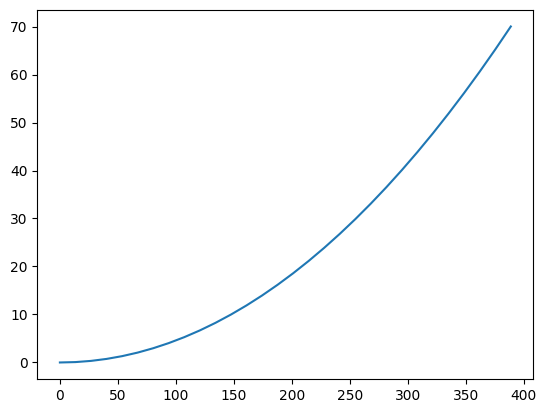

In [38]:
plt.plot(x0, z0)
plt.show()

In [39]:
q0=np.zeros(12*N)

In [40]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [41]:
h = length_p1[-1]/N

In [42]:
def fun1(x_int, φ, θ, ψ):
    x_arr = np.atleast_1d(x_int) 
    num_pts = len(x_arr)
    
    coeff_A = mp * 1/2 * (1 + x_arr) * 1/2 * (1 - x_arr)  
    coeff_D = 1/2 * (1 + x_arr) * 1/2 * (1 - x_arr)      
    
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_D = I_e_rho(φ, θ, ψ) @ Πe(φ, θ, ψ)
    
    A = np.multiply.outer(id3, coeff_A)
    B = np.zeros((3, 3, num_pts))
    D = np.multiply.outer(mat_D, coeff_D)
    
    block_top = np.concatenate([A, B], axis=1)     
    block_bottom = np.concatenate([B, D], axis=1)  
    total_matrix = np.concatenate([block_top, block_bottom], axis=0) 
    
    return h / 2 * total_matrix


def fun2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h):
    x_arr = np.atleast_1d(x_int)  
    num_pts = len(x_arr)
    
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_S = S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
    
    coeff_C = -1/2 * (1 + x_arr)  
    
    A = np.repeat(id3[:, :, np.newaxis], num_pts, axis=2)
    B = np.zeros((3, 3, num_pts))
    C = np.multiply.outer(mat_S, coeff_C)  
    
    block_top = np.concatenate([A, B], axis=1)      
    block_bottom = np.concatenate([C, A], axis=1)   
    total_matrix = np.concatenate([block_top, block_bottom], axis=0)  
    
    total_matrix = (h / 2) * total_matrix
    
    vec_ne = np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h))
    vec_me = np.asarray(me(φ1, θ1, ψ1))
    right_vector = np.concatenate((vec_ne, vec_me), axis=None) 
    
    return np.einsum('ijk,j->ik', total_matrix, right_vector)


def fun3(x_int, φ, θ, ψ, dφ, dθ, dψ):
  
    x_arr = np.atleast_1d(x_int)  
    num_pts = len(x_arr)
    
    A = np.zeros((3, num_pts))
    

    mat_prod = I_e_rho(φ, θ, ψ) @ dΠ(φ, θ, ψ, dφ, dθ, dψ) 
    vec_diff = np.array([dφ, dθ, dψ])                     
    static_B = mat_prod @ vec_diff                        
    
    coeff_B = 1/2 * (1 + x_arr)  
    
    B = np.multiply.outer(static_B, coeff_B)  
    
    total_matrix = np.concatenate((A, B), axis=0)  
    
    return (h / 2) * total_matrix


def fun4(x_int, φ, θ, ψ, dφ, dθ, dψ):
    A = np.zeros(3)
    ang_vel = Πe(φ, θ, ψ) @ np.array([dφ, dθ, dψ])
    B_base = S(*ang_vel) @ (I_e_rho(φ, θ, ψ) @ ang_vel)
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    B_scaled = 1/2 * (1 + x_arr) * B_base 
    A_repeated = np.tile(A, (len(B_scaled), 1)) 
    

    result = h / 2 * np.hstack((A_repeated, B_scaled)) 
    
    return result if np.isscalar(x_int) else result.T


def fun5(x_int,x,y,z,li):
    B = np.zeros(3)   
    A_base = 1/2 * fe_g(x,y,z)*li
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis]
    A_scaled = (1 + x_arr) * A_base
    B_repeated = np.tile(B, (len(A_scaled), 1))
    
    result = h / 2 * np.hstack((A_scaled, B_repeated))
    
    return result if np.isscalar(x_int) else result.T


def fun6(x_int, φ, θ, ψ, dx, dy, dz, dφ, dθ, dψ):
    A_base = Ret_e_t(φ, θ, ψ) @ f_t_d(dx, dy, dz)
    B_base = DR @ Πe(φ, θ, ψ) @ np.array([dφ, dθ, dψ])
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    
    A_scaled = 1/2 * (1 + x_arr) * A_base 
    B_scaled = 1/2 * (1 + x_arr) * B_base 
    
    result = h / 2 * np.hstack((A_scaled, B_scaled)) 
    
    return result[0] if np.isscalar(x_int) else result.T


def fun7(x_int, x, y, z):
    A_base = sigma(x, y, z) 
    B_base = np.zeros(3)   
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    
    A_scaled = 1/2 * (1 + x_arr) * A_base          
    B_scaled = np.tile(B_base, (len(A_scaled), 1)) 
    
    result = h / 2 * np.hstack((A_scaled, B_scaled))
    
    return result if np.isscalar(x_int) else result.T

In [43]:
def Assemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]    
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]
    
    return K

In [44]:
def static_solution(Q): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    
    f2=np.zeros(6*N) 
    f3=np.zeros(6*N) 
    f4=np.zeros(6*N) 
    f5=np.zeros(6*N) 
    f6=np.zeros(6*N) 
    f7=np.zeros(6*N)
       
    K_stat=np.zeros(shape=(6*N,6*N))
    for j in range(1,N):
        block = np.block([[integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j-1],θ[j-1],ψ[j-1]),-1.0,1.0,n=2)[0],
                           -integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j-1],θ[j-1],ψ[j-1]),-1.0,1.0,n=2)[0]],
                          [integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j],θ[j],ψ[j]),-1.0,1.0,n=2)[0],
                           -integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j],θ[j],ψ[j]),-1.0,1.0,n=2)[0]]])
        K_stat = Assemble(K_stat,block,j-1,j)
        start = 6*(j-1)
        end = start + 6
        f2[start:end] += integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],h),-1.0,1.0,n=2)[0]
        f3[start:end] += integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1]),-1.0,1.0,n=2)[0]
        f4[start:end] += integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1]),-1.0,1.0,n=2)[0]
        f5[start:end] += integrate.fixed_quad(lambda x_int: fun5(x_int,x[j-1],y[j-1],z[j-1], h),-1.0, 1.0, n=2)[0]
        f6[start:end] += integrate.fixed_quad(lambda x_int: fun6(x_int,φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1]),-1.0,1.0,n=2)[0]
        f7[start:end] += integrate.fixed_quad(lambda x_int: fun7(x_int,x[j-1],y[j-1],z[j-1]),-1.0,1.0,n=2)[0]
    


    F=(
#         f2
        +f3
        +f4
        +f5
        +f6
#         +f7
    )  
    

    bc=np.array([[0,1,2,3,4,5], 
                 [0,0,0,0,0,0]]).T
    
    nd, nd=K_stat.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    
    K_stat[np.isnan(K_stat)] = 0
    F[np.isnan(F)] = 0
    
    s=scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(K_stat[fdof,:][:,fdof]) ,
                      (F[fdof].T-np.dot(K_stat[fdof,:][:,pdof],dp.T)).T) 
    
 
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    
   
    ddx,ddy,ddz,ddφ,ddθ,ddψ=d.reshape(N,6).T
    
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [45]:
root_ = root(static_solution, q0, method='lm')

In [46]:
root_

 message: Both actual and predicted relative reductions in the sum of squares
            are at most 0.000000 and the relative error between two consecutive iterates is at 
            most 0.000000
 success: True
  status: 3
     fun: [ 0.000e+00  0.000e+00 ... -0.000e+00 -0.000e+00]
       x: [ 0.000e+00  1.341e+01 ...  0.000e+00  0.000e+00]
   cov_x: None
  method: lm
    nfev: 362
    fjac: [[-1.029e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -1.029e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -0.000e+00]]
    ipvt: [212 272 ...  65 150]
     qtf: [ 0.000e+00  0.000e+00 ...  9.035e+01  9.035e+01]

In [47]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [48]:
q0 = root_.x                                         # start from static solution

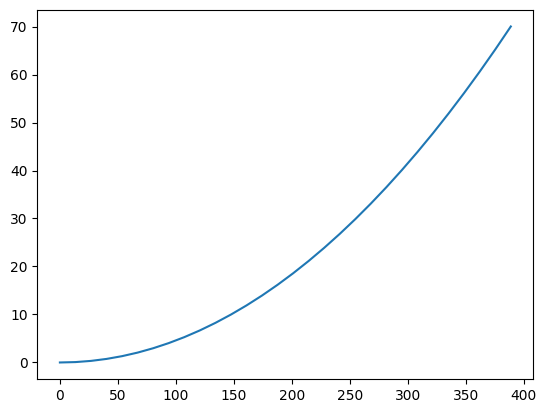

In [49]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [50]:
sampleTime = 0.001              # sample time [seconds]
Number = 60000                      # number of samples

In [51]:
Number*sampleTime

60.0

In [52]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [53]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [54]:
simData.shape 

(60001, 24)

In [55]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

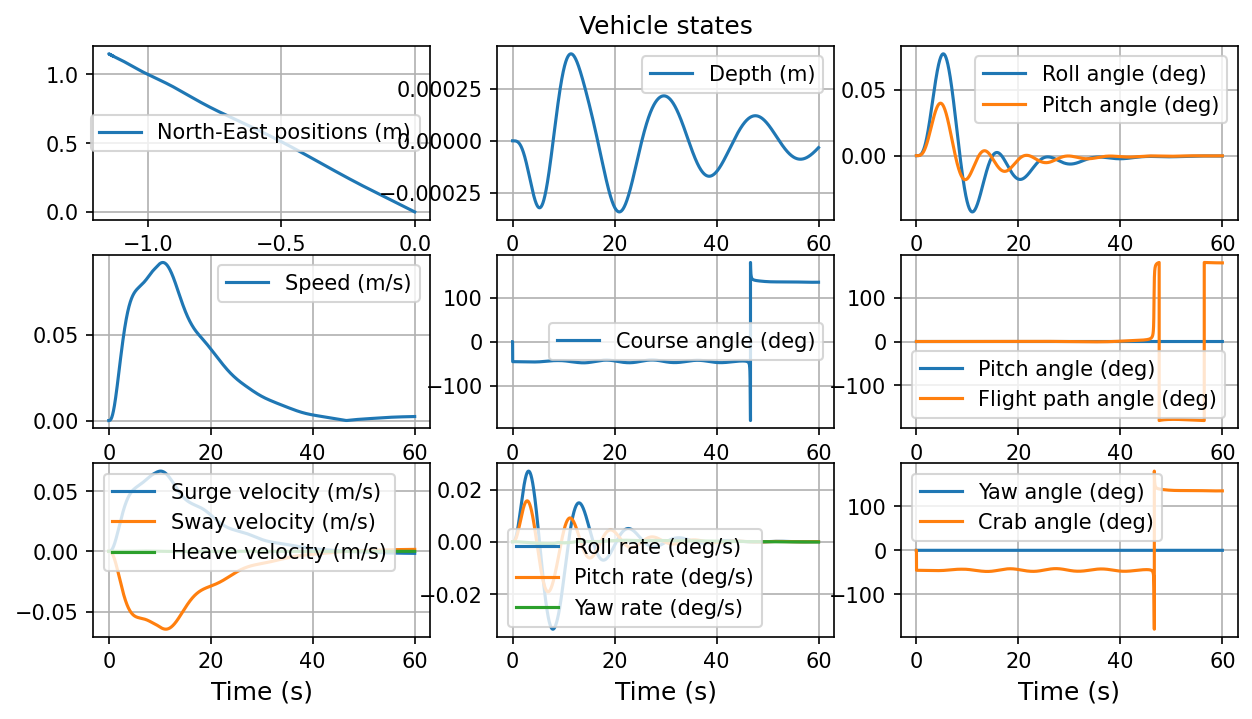

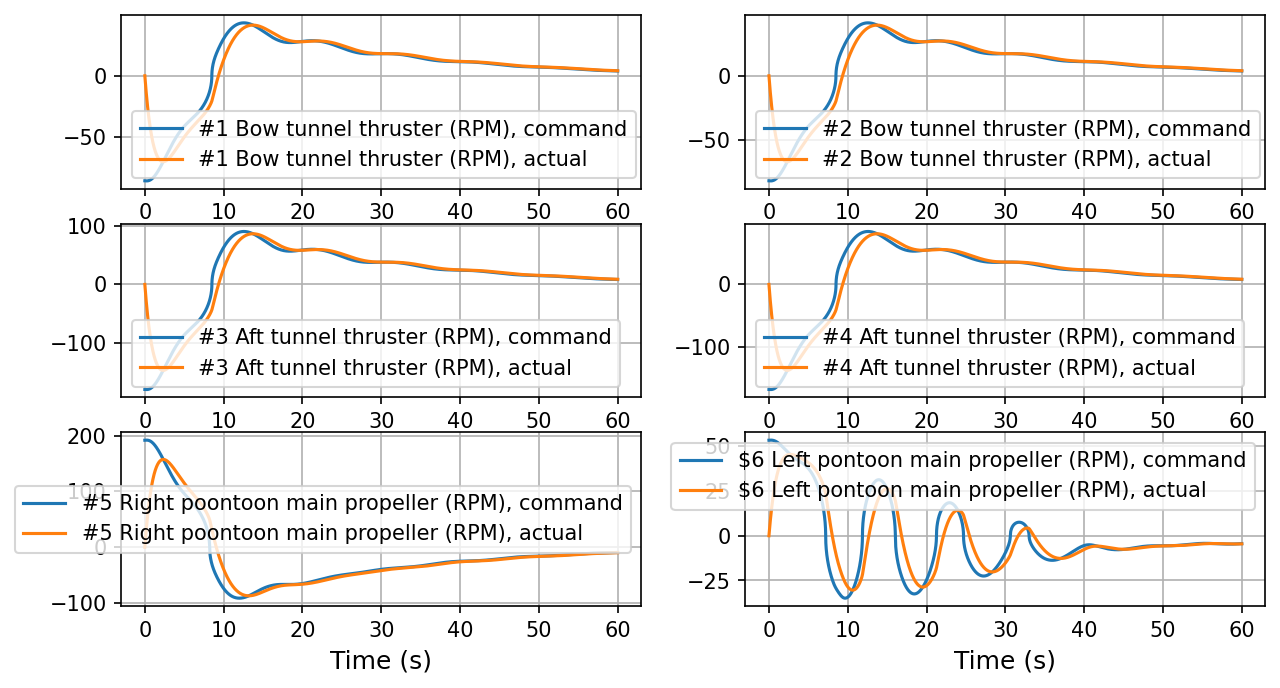

In [56]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [57]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

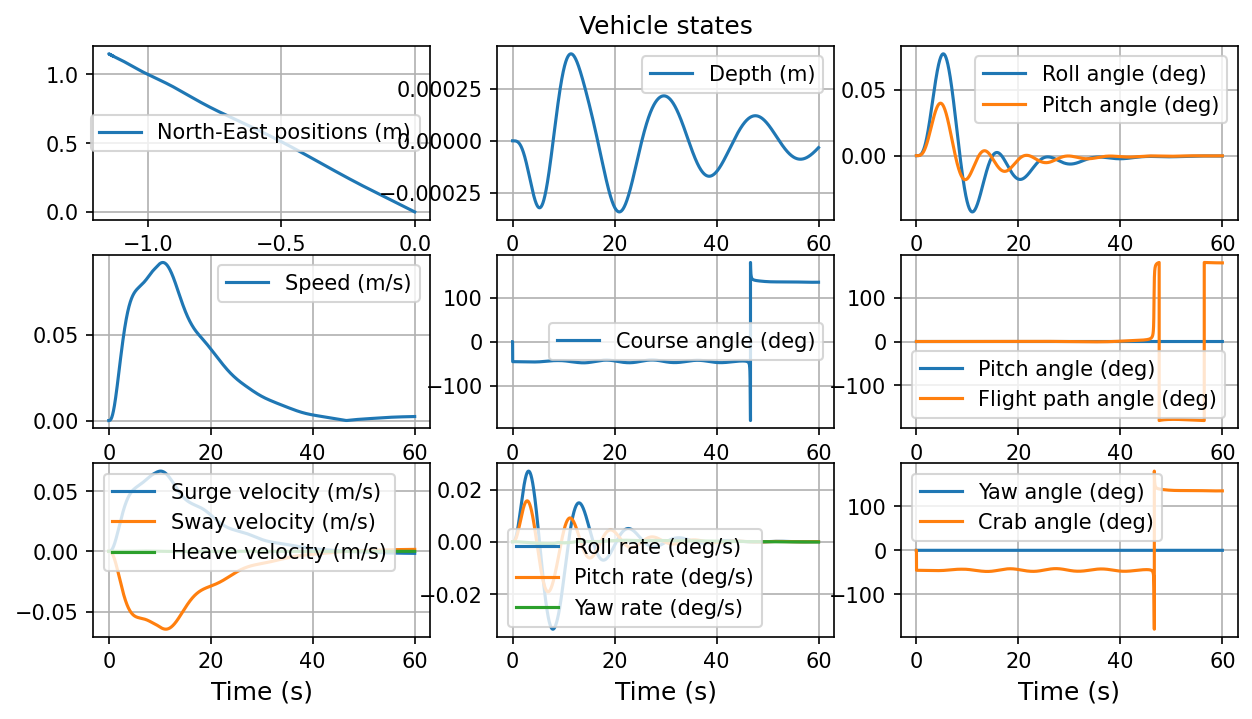

In [58]:
plotVehicleStates(simTime, simData, 3)

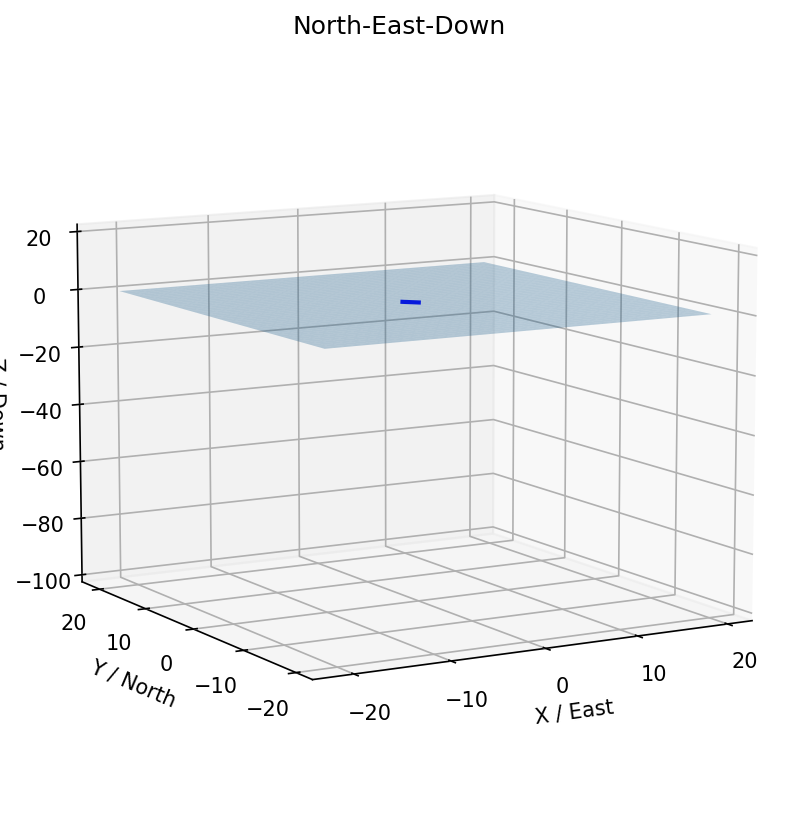

In [59]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [60]:
simData.shape

(60001, 24)

In [61]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [247]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        self.force_factor = 1e-04
        self.soil_factor = 1e-02

In [248]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 18:24], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamic Simulation

In [249]:
def dynamic_func(t, Q, T):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    u_actual = T.force_factor*vessel_motion_func(t)

    u_actual_x = u_actual[0]
    u_actual_y = u_actual[1]
    u_actual_z = u_actual[2]
    u_actual_phi = u_actual[3]
    u_actual_theta = u_actual[4]
    u_actual_psi = u_actual[5]
        
        
    f2=np.zeros(6*N) 
    f3=np.zeros(6*N) 
    f4=np.zeros(6*N) 
    f5=np.zeros(6*N) 
    f6=np.zeros(6*N) 
    f7=np.zeros(6*N) 
    f8=np.zeros(6*N)
    
    K_stat=np.zeros(shape=(6*N,6*N))
    for j in range(1,N):
        block = np.block([[integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j-1],θ[j-1],ψ[j-1]),-1.0,1.0,n=2)[0],
                           -integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j-1],θ[j-1],ψ[j-1]),-1.0,1.0,n=2)[0]],
                          [integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j],θ[j],ψ[j]),-1.0,1.0,n=2)[0],
                           -integrate.fixed_quad(lambda x_int: fun1(x_int,φ[j],θ[j],ψ[j]),-1.0,1.0,n=2)[0]]])
        K_stat = Assemble(K_stat,block,j-1,j)
        start = 6*(j-1)
        end = start + 6
        f2[start:end] += integrate.fixed_quad(lambda x_int:fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],h),-1.0,1.0,n=1)[0]
        f3[start:end] += integrate.fixed_quad(lambda x_int:fun3(x_int, φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1]),-1.0,1.0,n=2)[0]
        f4[start:end] += integrate.fixed_quad(lambda x_int:fun4(x_int, φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1]),-1.0,1.0,n=2)[0]
        f5[start:end] += integrate.fixed_quad(lambda x_int:fun5(x_int, x[j-1],y[j-1],z[j-1], h),-1.0,1.0,n=2)[0]
        f6[start:end] += integrate.fixed_quad(lambda x_int: fun6(x_int,φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1]),-1.0,1.0,n=2)[0]
        f7[start:end] += integrate.fixed_quad(lambda x_int: fun7(x_int,x[j-1],y[j-1],z[j-1]),-1.0,1.0,n=2)[0]
       
        if t>0.001:
            ax=np.linalg.inv(Ret_e_t(φ[j-1],θ[j-1],ψ[j-1]))@ ne(x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1],x[j], y[j], z[j],h).T

            T.top_tension=max(T.top_tension, ax[0][0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j-1],θ[j-1],ψ[j-1])) @ me( φ[j-1], θ[j-1], ψ[j-1]).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)
            
    f8[-6:] += (np.block([[np.identity(3), np.zeros((3,3))], 
                          [np.zeros((3,3)), np.identity(3)]])@u_actual)    
    
    F=(
#         f2
       + f3 + f4 + f5 + f6
        - T.soil_factor*f7
        - f8)  
    
    bc=np.array([[0,1,2,3,4,5], 
                 [0,0,0,0,0,0]]).T
    nd, nd=K_stat.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    
    K_stat[np.isnan(K_stat)] = 0
    F[np.isnan(F)] = 0
    
    s=scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(K_stat[fdof,:][:,fdof]) ,
                      (F[fdof].T-np.dot(K_stat[fdof,:][:,pdof],dp.T)).T) 
    
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
     
    ddx,ddy,ddz,ddφ,ddθ,ddψ=d.reshape(N,6).T
        
        
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
   
    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now()  
        
        
    T.my_iter+=1 
    
    return ans

In [250]:
T_ = MyTime()

In [251]:
# initial conditions 
BC=np.zeros(N)
BC[-1] = 0.013
q0[8*N:9*N] = BC

In [252]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func, tspan, q0, args=(T_, )
                , method='RK23'
               )
print(datetime.now() - startTime1)

Physical time:  6.560628461171736e-09  Iteration wall-clock time:  0:00:00.788224
Physical time:  1.0000903212143746  Iteration wall-clock time:  0:01:09.055420
0:02:25.248191


### Results

In [253]:
# number of iterations
T_.my_iter

7832

In [254]:
# max axial tension
T_.top_tension

0

In [255]:
# max bending strain
T_.sagbend_strain

0.033652030188120866

In [256]:
fin=us_

In [257]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.561e-07 ...  2.000e+00  2.000e+00]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 1.341e+01  1.341e+01 ...  1.343e+01  1.343e+01]
            ...
            [ 0.000e+00 -1.720e-25 ... -2.710e-06 -2.712e-06]
            [ 0.000e+00  2.497e-18 ...  1.026e-05  1.026e-05]]
      sol: None
 t_events: None
 y_events: None
     nfev: 7832
     njev: 0
      nlu: 0

In [258]:
t=fin.t

In [259]:
fin=fin.y.T

In [260]:
t.shape, fin.shape

((1903,), (1903, 360))

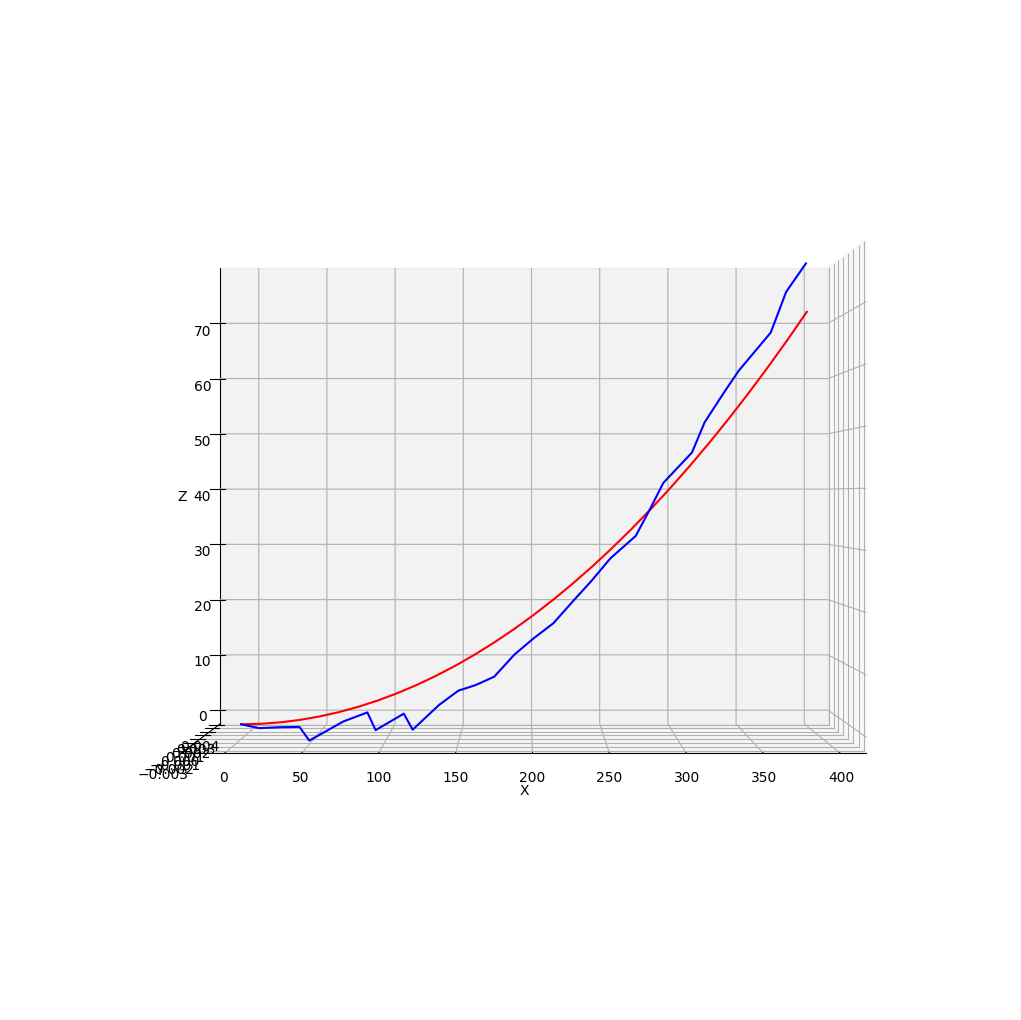

In [261]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [262]:
X,Y,Z

(array([  0.        ,  13.42964958,  26.82839653,  40.25910111,
         53.65694788,  67.08856603,  80.48716162,  93.91793467,
        107.3193466 , 120.74703011, 134.1527248 , 147.5758911 ,
        160.98568848, 174.40449064, 187.81809685, 201.23280487,
        214.64995043, 228.06088482, 241.48096207, 254.888842  ,
        268.31109606, 281.7168583 , 295.14011026, 308.54515518,
        321.96786746, 335.37396807, 348.79419118, 362.20346526,
        375.61912312, 389.03377187]),
 array([ 0.00000000e+00, -4.31997788e-04, -2.27453768e-04, -7.99700368e-05,
        -2.95424002e-03,  1.63551708e-03,  3.75196409e-03, -9.39311518e-04,
         3.49324084e-03, -2.36239049e-03,  2.15586113e-03,  2.54262749e-03,
        -2.88958553e-05, -1.34394477e-03,  1.78124566e-03,  2.78041712e-03,
        -2.64825905e-04,  5.36283014e-04,  8.00269027e-04,  1.04621658e-03,
        -2.51531686e-03,  3.25928838e-04,  3.20312233e-03, -8.19402370e-04,
         1.68053948e-03,  1.67097981e-03,  2.82419211e-03,

In [263]:
X0,Y0,Z0

(array([  0.        ,  13.41472778,  26.82945556,  40.24418334,
         53.65891113,  67.07363891,  80.48836669,  93.90309447,
        107.31782225, 120.73255003, 134.14727781, 147.5620056 ,
        160.97673338, 174.39146116, 187.80618894, 201.22091672,
        214.6356445 , 228.05037229, 241.46510007, 254.87982785,
        268.29455563, 281.70928341, 295.12401119, 308.53873897,
        321.95346676, 335.36819454, 348.78292232, 362.1976501 ,
        375.61237788, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([ 0.        ,  0.08237129,  0.32949759,  0.74141617,  1.31818915,
         2.05990351,  2.96667113,  4.03862874,  5.27593802,  6.67878558,
         8.24738297,  9.98196678, 11.88279859, 13.95016508, 16.18437804,
        18.58577443, 21.15471639, 23.89159138, 26.79681215, 29.87081684,
        33.11406907, 36.52705795, 40.11029823, 43.86433029, 47.78972031,
        51.

In [264]:
us=fin.T

In [265]:
us.shape

(360, 1903)

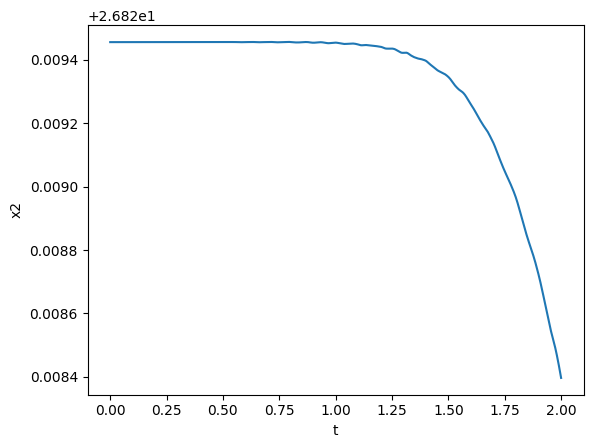

In [266]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

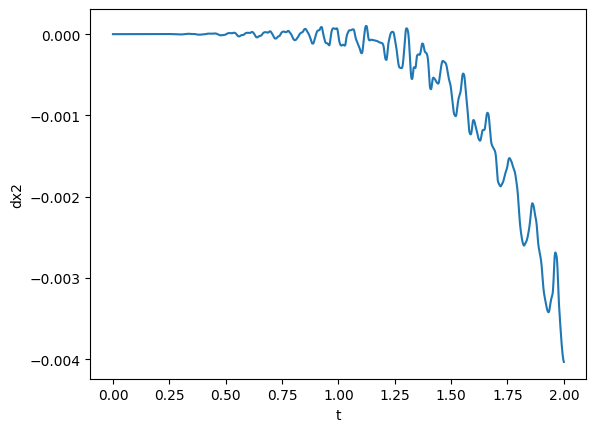

In [267]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

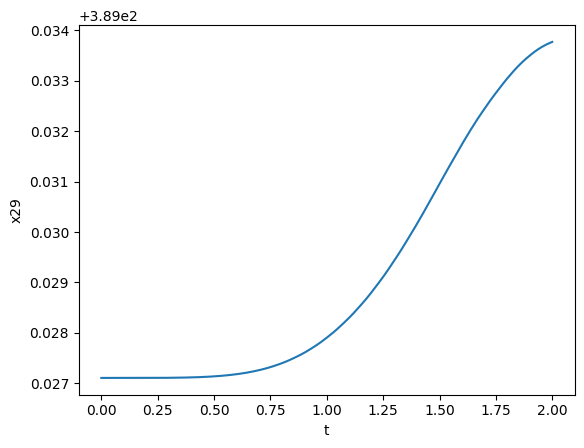

In [268]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

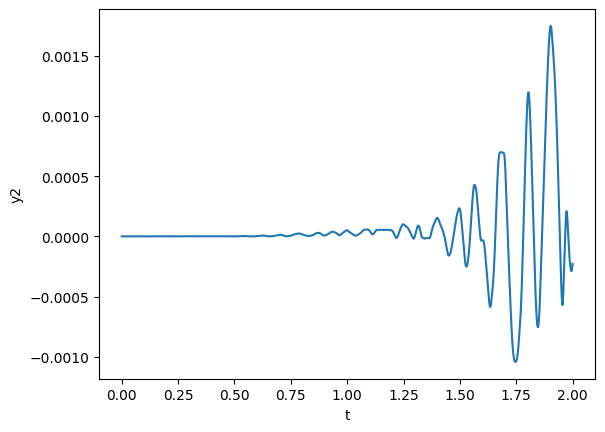

In [269]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

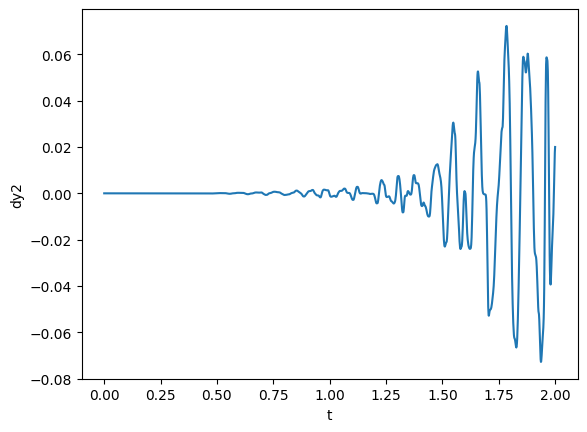

In [270]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

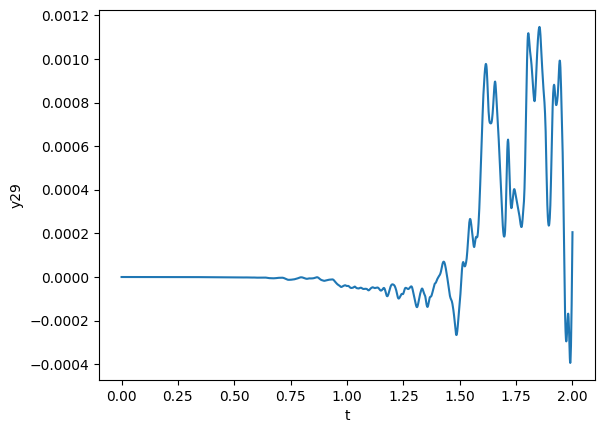

In [271]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

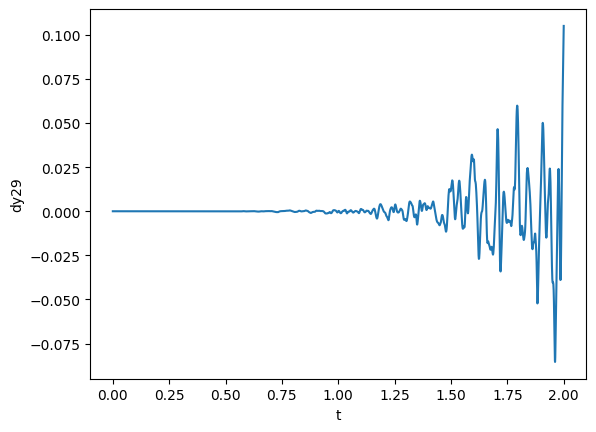

In [272]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

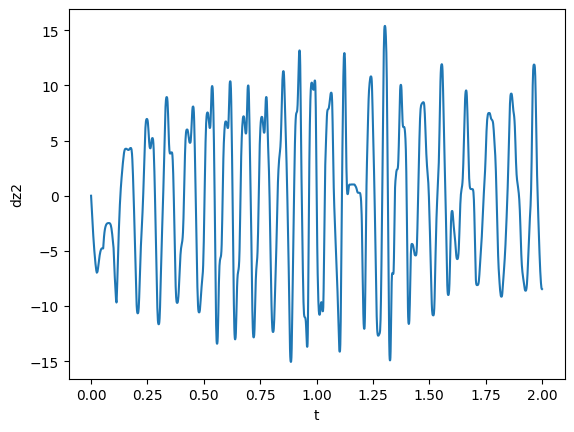

In [273]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

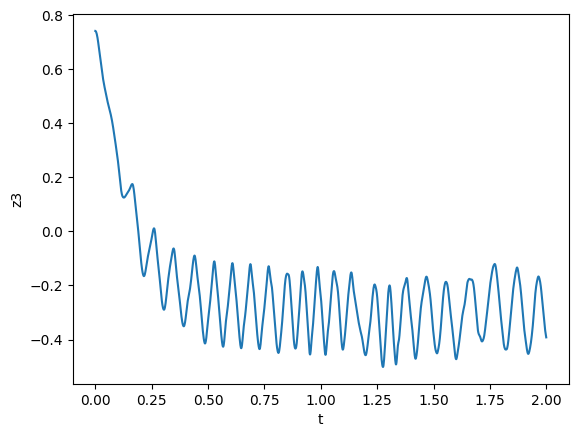

In [274]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

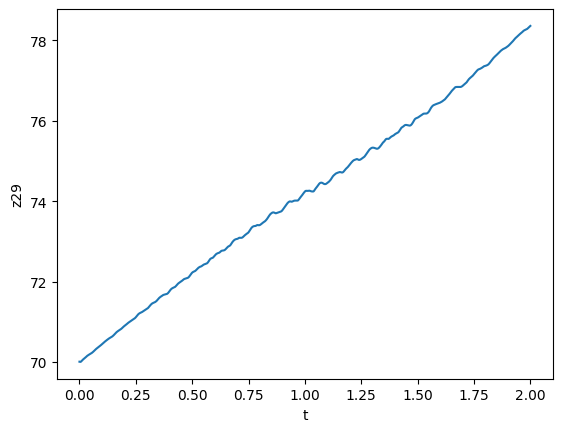

In [275]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

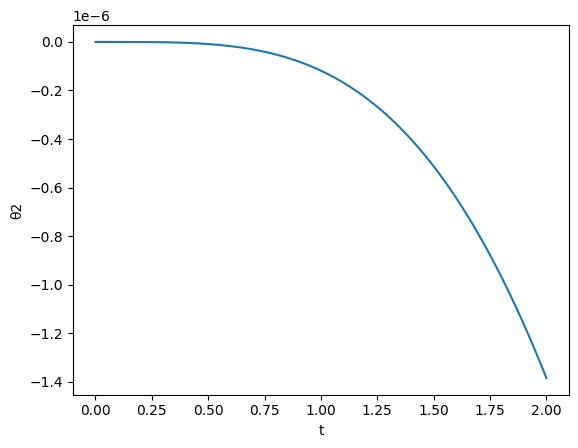

In [276]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

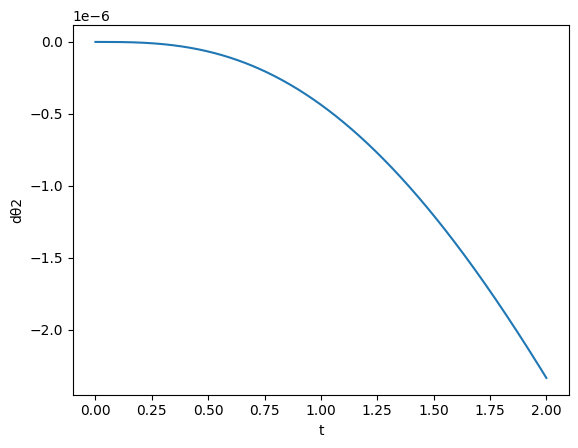

In [277]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

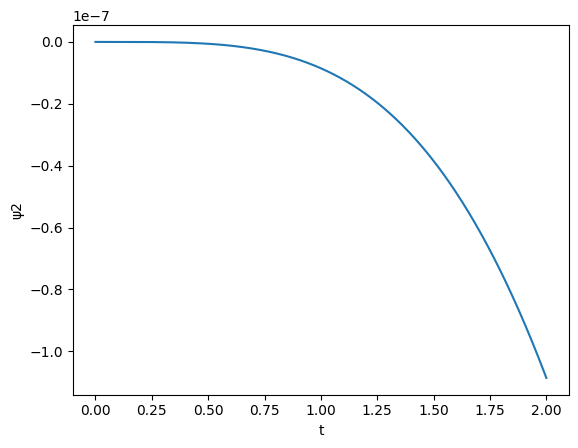

In [278]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

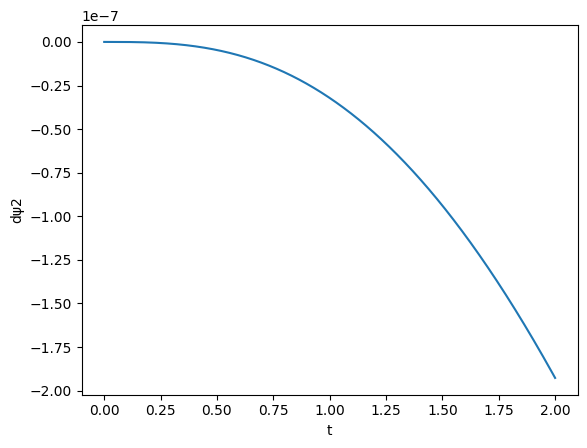

In [279]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

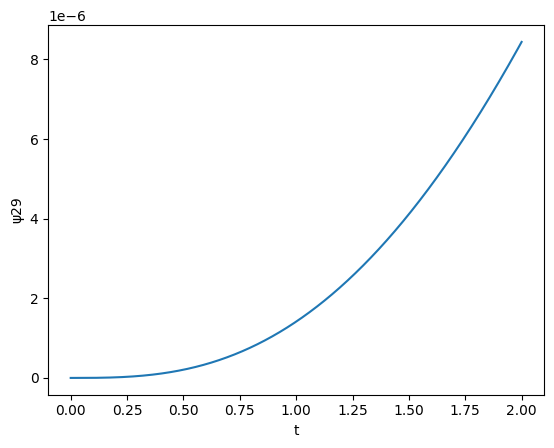

In [280]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [281]:
X010=us.T[:,0*N:1*N]

In [282]:
Y010=us.T[:,2*N:3*N]

In [283]:
Z010=us.T[:,4*N:5*N]

In [284]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()